---
# 1) Import Libraries & Data

## a) Import the required libraries

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

## b) Load the raw dataset containing the trajectories

In [94]:
df = pd.read_parquet("dataDumper.parquet")
df.head(3)

,Time_utc,VehicleName,VehicleType,Pressure_Pa_1,Pressure_Pa_2,Pressure_Pa_3,Pressure_Pa_4,Pressure_Pa_5,Pressure_Pa_6,Temperature_K_1,...,Altitude_m,Speed_mps,epsilonX,epsilonY,epsilonZ,epsilonSpeed,AtmosphericPressure_Pa,dt_s,dd_m,RatioPayload
0,2023-01-01 00:00:00.328,C-132,Dumper,993010.933333,1.003995e+06,856000.0,798005.466667,819994.533333,864994.533333,346.15,...,4581.000000,9.003,6.207,6.312,23.000000,0.0,59002.557667,4.912,41.480140,0.0
1,2023-01-01 00:00:05.338,C-132,Dumper,993177.933329,1.003911e+06,856000.0,798088.966665,819911.033335,864911.033335,346.15,...,4577.600098,9.003,6.393,6.797,27.600000,0.0,59028.296172,5.010,45.952211,0.0
2,2023-01-01 00:00:10.331,C-132,Dumper,993344.366669,1.003828e+06,856000.0,798172.183334,819827.816666,864827.816666,346.15,...,4573.000000,9.723,6.721,7.631,32.200001,0.0,59064.789917,4.993,47.007842,0.0


In [95]:
# Display all columns (variables) in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201312 entries, 0 to 201311
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time_utc                201312 non-null  object 
 1   VehicleName             201312 non-null  object 
 2   VehicleType             201312 non-null  object 
 3   Pressure_Pa_1           198245 non-null  float64
 4   Pressure_Pa_2           201106 non-null  float64
 5   Pressure_Pa_3           201190 non-null  float64
 6   Pressure_Pa_4           201088 non-null  float64
 7   Pressure_Pa_5           201178 non-null  float64
 8   Pressure_Pa_6           201158 non-null  float64
 9   Temperature_K_1         198245 non-null  float64
 10  Temperature_K_2         201106 non-null  float64
 11  Temperature_K_3         201190 non-null  float64
 12  Temperature_K_4         201088 non-null  float64
 13  Temperature_K_5         201178 non-null  float64
 14  Temperature_K_6     

## c) Process the raw trajectory data

In [96]:
# Convert the 'Time_utc' column to datetime format
df["Time_utc"] = pd.to_datetime(df["Time_utc"], format='mixed', errors='coerce')


In [97]:
# Create Segments (trajectory identifier) based on  RatioPayLoad
df['phaseNb'] = df['RatioPayload'].diff().abs().cumsum().astype(int, errors="ignore")

---
# 2) Missing Values (NaN) Analysis

In this second part, we will analyze the rows with missing values for the available variables, meaning the rows where certain variables have missing data (NaN or otherwise).

## a) Global analysis

In [73]:
# Variables with at least one missing value
df.isna().any()

Time_utc                  False
VehicleName               False
VehicleType               False
Pressure_Pa_1              True
Pressure_Pa_2              True
Pressure_Pa_3              True
Pressure_Pa_4              True
Pressure_Pa_5              True
Pressure_Pa_6              True
Temperature_K_1            True
Temperature_K_2            True
Temperature_K_3            True
Temperature_K_4            True
Temperature_K_5            True
Temperature_K_6            True
ColdPressure_Pa_1          True
ColdPressure_Pa_2          True
ColdPressure_Pa_3          True
ColdPressure_Pa_4          True
ColdPressure_Pa_5          True
ColdPressure_Pa_6          True
Latitude_dd               False
Longitude_dd              False
Altitude_m                False
Speed_mps                 False
epsilonX                  False
epsilonY                  False
epsilonZ                  False
epsilonSpeed              False
AtmosphericPressure_Pa     True
dt_s                      False
dd_m    

In [74]:
# Count the missing values for each variable
na_counts = df.isna().sum()
na_percent = ((na_counts / len(df)) * 100).round(2)
na_summary = pd.DataFrame({
    'na_count': na_counts,
    'na_percent': na_percent
}).sort_values('na_count', ascending=False)

na_summary

,na_count,na_percent
Temperature_K_1,3067,1.52
Pressure_Pa_1,3067,1.52
ColdPressure_Pa_1,3067,1.52
dd_m,2634,1.31
AtmosphericPressure_Pa,957,0.48
ColdPressure_Pa_4,224,0.11
Temperature_K_4,224,0.11
Pressure_Pa_4,224,0.11
Temperature_K_2,206,0.10
ColdPressure_Pa_2,206,0.10


We can see that each set of tire variables (temperature, pressure, and cold pressure) has the same number of missing values for each tire.  
-> This suggests that when a measurement is missing for a given tire, all three tire variables are missing.  
This probably means that these missing values are caused by issues associated with the tire sensors.

## b) Analyze the missing values for Tire 1 (front-left)

In [75]:
# Define the columns associated with this tire
tire1_df = df[[
    "Time_utc", "VehicleName", "VehicleType", "Pressure_Pa_1", "Temperature_K_1", "ColdPressure_Pa_1",
    "Latitude_dd", "Longitude_dd", "Altitude_m","Speed_mps", "epsilonX", "epsilonY", "epsilonZ",
    "epsilonSpeed","AtmosphericPressure_Pa", "dt_s", "dd_m", "RatioPayload", "phaseNb"
    ]]

In [76]:
# Identify rows with missing values in tire variables
mask_tire1_na_values = tire1_df[["Pressure_Pa_1", "Temperature_K_1", "ColdPressure_Pa_1"]].isna()

# Check our hypothesis about the correlation of missing values among the variables of the same tire
mask_tire1_na_values[(mask_tire1_na_values.sum(axis = 1) > 0) & (mask_tire1_na_values.sum(axis = 1) < 3)]

,Pressure_Pa_1,Temperature_K_1,ColdPressure_Pa_1


-> For Tire 1, there are no records where only one of the three tire variables is missing while the others are present.

In [77]:
# Get the indices of rows with at least one missing value in a tire variable
tire1_na_values_df = tire1_df[mask_tire1_na_values.any(axis = 1)]
tire1_na_values_index = tire1_na_values_df.index

Create a loop to display trajectories (phases) that contain at least one record with a missing value.  
Blue points correspond to records without missing values, while red points correspond to records with at least one missing value.

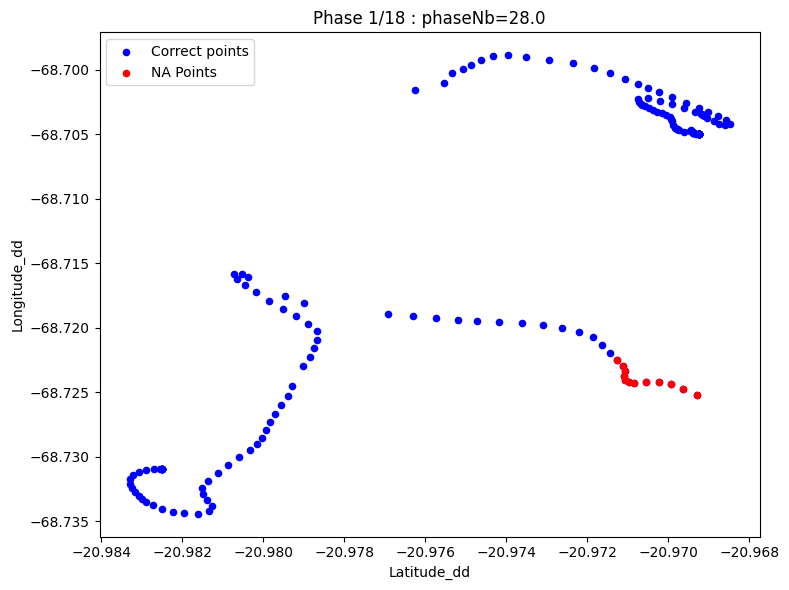

In [78]:
phases = tire1_na_values_df["phaseNb"].unique().tolist()
print(f"Number of phases with missing values : {len(phases)}")

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    tire1_df_sample = tire1_df[tire1_df["phaseNb"] == phase_nb]
    tire1_na_values_sample_df = tire1_na_values_df[tire1_na_values_df["phaseNb"] == phase_nb]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(tire1_df_sample['Latitude_dd'], tire1_df_sample['Longitude_dd'], s=20, c="blue", label="Correct points")
    ax.scatter(tire1_na_values_sample_df['Latitude_dd'], tire1_na_values_sample_df['Longitude_dd'], s=20, c="red", label="NA Points")
    ax.set_title(f"Phase {i+1}/{len(phases)} : phaseNb={phase_nb}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    if i < len(phases)-1:
        resp = input('Press Enter to proceed to the next phase (or type "N" to exit the loop)...')
        if resp == "N":
            break

We can see that records with at least one missing value are mostly consecutive and are often followed by missing records in other variables as well (including GPS coordinates).  
This likely indicates that these sequences correspond to periods when the sensors stop transmitting data due to issues with the 3G network—for example, when the vehicle is deep in the mine and the network is too weak to even transmit GPS coordinates.

## c) Analyze the missing values for Tire 2 (front-right)

In this section, we realize the same missing values analysis for the tire 2 (front-right)

In [79]:
# Define the columns associated with this tire
tire2_df = df[[
    "Time_utc", "VehicleName", "VehicleType", "Pressure_Pa_2", "Temperature_K_2", "ColdPressure_Pa_2",
    "Latitude_dd", "Longitude_dd", "Altitude_m","Speed_mps", "epsilonX", "epsilonY", "epsilonZ",
    "epsilonSpeed","AtmosphericPressure_Pa", "dt_s", "dd_m", "RatioPayload", "phaseNb"
    ]]

In [80]:
# Identify rows with missing values in tire variables
mask_tire2_na_values = tire2_df[["Pressure_Pa_2", "Temperature_K_2", "ColdPressure_Pa_2"]].isna()

# Check our hypothesis about the correlation of missing values among the variables of the same tire
mask_tire2_na_values[(mask_tire2_na_values.sum(axis = 1) > 0) & (mask_tire2_na_values.sum(axis = 1) < 3)]

,Pressure_Pa_2,Temperature_K_2,ColdPressure_Pa_2


-> For Tire 2, there are no records where only one of the three tire variables is missing while the others are present.

In [81]:
# Get the indices of rows with at least one missing value in a tire variable
tire2_na_values_df = tire2_df[mask_tire2_na_values.any(axis = 1)]
tire2_na_values_index = tire2_na_values_df.index

Create a loop to display trajectories (phases) that contain at least one record with a missing value.  
Blue points correspond to records without missing values, while red points correspond to records with at least one missing value.

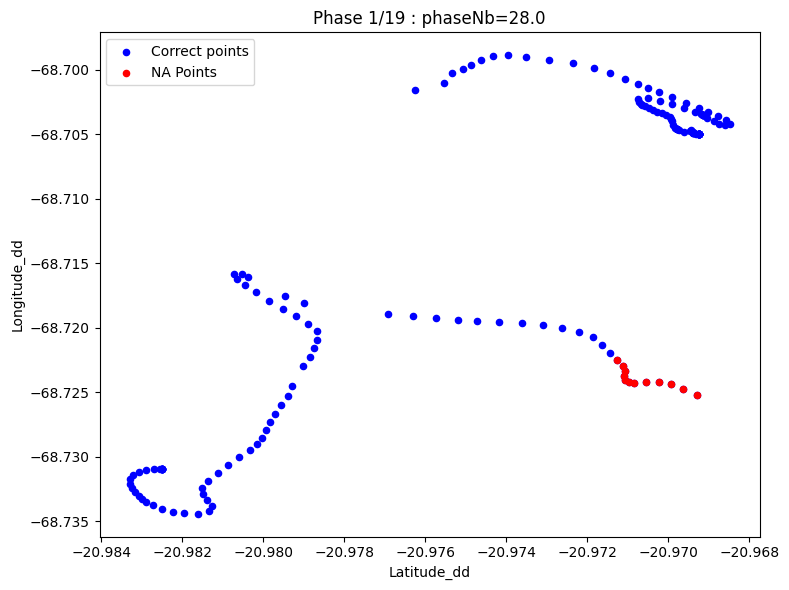

In [82]:
phases = tire2_na_values_df["phaseNb"].unique().tolist()
print(f"Number of phases with missing values : {len(phases)}")

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    tire2_df_sample = tire2_df[tire2_df["phaseNb"] == phase_nb]
    tire2_na_values_sample_df = tire2_na_values_df[tire2_na_values_df["phaseNb"] == phase_nb]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(tire2_df_sample['Latitude_dd'], tire2_df_sample['Longitude_dd'], s=20, c="blue", label="Correct points")
    ax.scatter(tire2_na_values_sample_df['Latitude_dd'], tire2_na_values_sample_df['Longitude_dd'], s=20, c="red", label="NA Points")
    ax.set_title(f"Phase {i+1}/{len(phases)} : phaseNb={phase_nb}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    if i < len(phases)-1:
        resp = input('Press Enter to proceed to the next phase (or type "N" to exit the loop)...')
        if resp == "N":
            break

As with Tire 1, we can see that records with at least one missing value are mostly consecutive and are often followed by missing records in other variables as well (including GPS coordinates).  
Therefore, we can draw the same conclusions as we did for Tire 1.

We have not included the missing values analysis for the other tires because we reach the same conclusions, so it is unnecessary to include them here.

## d) Analyze missing values for the Atmospheric Pressure variable

In this section, we will analyze records with missing values for the "Atmospheric Pressure" variable, which are not related to any specific tire.

In [83]:
# Define the columns associated with this variable
appa_df = df[[
    "Time_utc", "VehicleName", "VehicleType", "AtmosphericPressure_Pa", "Latitude_dd", "Longitude_dd",
    "Altitude_m","Speed_mps", "epsilonX", "epsilonY", "epsilonZ", "epsilonSpeed","AtmosphericPressure_Pa", "dt_s", "dd_m", "RatioPayload",
    "phaseNb"
    ]]

In [84]:
# Identify rows with missing values in this variable
mask_appa_na_values = appa_df[["AtmosphericPressure_Pa"]].isna()
appa_na_values_df = appa_df[mask_appa_na_values.any(axis = 1)]
appa_na_values_index = appa_na_values_df.index

Create a loop to display trajectories (phases) that contain at least one record with a missing value.  
Blue points correspond to records without missing values, while red points correspond to records with at least one missing value.

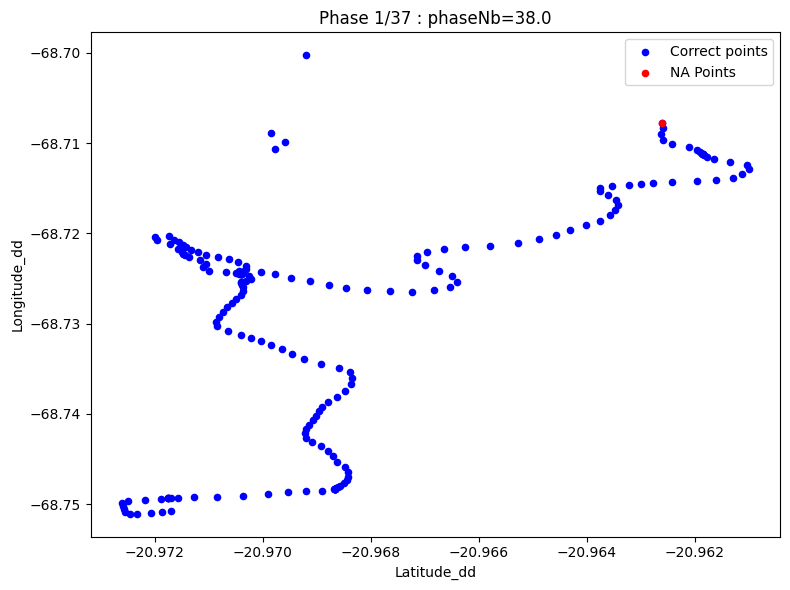

In [85]:
phases = appa_na_values_df["phaseNb"].unique().tolist()
print(f"Number of phases with missing values : {len(phases)}")

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    appa_df_sample = appa_df[appa_df["phaseNb"] == phase_nb]
    appa_na_values_sample_df = appa_na_values_df[appa_na_values_df["phaseNb"] == phase_nb]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(appa_df_sample['Latitude_dd'], appa_df_sample['Longitude_dd'], s=20, c="blue", label="Correct points")
    ax.scatter(appa_na_values_sample_df['Latitude_dd'], appa_na_values_sample_df['Longitude_dd'], s=20, c="red", label="NA Points")
    ax.set_title(f"Phase {i+1}/{len(phases)} : phaseNb={phase_nb}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    if i < len(phases)-1:
        resp = input('Press Enter to proceed to the next phase (or type "N" to exit the loop)...')
        if resp == "N":
            break

Logically, we reach the same conclusions as in the two previous sections regarding the missing records.

## e) Missing records analysis

In this final section of the Missing Values Analysis, we will identify and analyze missing records for the vehicle within the trajectories.  

To do this, we will use the fact that each GPS coordinate and other variables, such as tire pressures, atmospheric pressure, etc., are recorded every 5 seconds.  

Moreover, we have a variable called "dt_s," which corresponds to the elapsed time since the previous record within a trajectory.  
Therefore, if the "dt_s" value is 10 seconds, we can deduce that one record is missing before it.

In [87]:
# Set the tolerance for the time interval between two records (in seconds)
dt_s_tolerance = 0.5
# Expected time interval between two records (in seconds)
original_dt_s = 5

# Initialize a column indicating no missing records by default
df["missing_record"] = False

# Mark as True the rows where the time gap exceeds the tolerance (potentially missing records)
df.loc[(df["dt_s"] - original_dt_s).abs() > dt_s_tolerance, "missing_record"] = True

# Display the first rows to check the result
df[["Time_utc", "Latitude_dd", "Longitude_dd", "dt_s", "missing_record"]].head(3)

,Time_utc,Latitude_dd,Longitude_dd,dt_s,missing_record
0,2023-01-01 00:00:00.328,-20.960378,-68.708935,4.912,False
1,2023-01-01 00:00:05.338,-20.960730,-68.709170,5.010,False
2,2023-01-01 00:00:10.331,-20.961045,-68.709473,4.993,False


In [88]:
# Create a DataFrame with only the rows where a missing record was detected
missing_records_df = df[df["missing_record"]][["Latitude_dd", "Longitude_dd", "dt_s", "missing_record", "phaseNb"]].copy()

# Calculate the number of missing records for each row based on the time gap
missing_records_df["nb_missing_records"] = ((missing_records_df["dt_s"] - original_dt_s) / original_dt_s).round(2)

# Display the resulting DataFrame
missing_records_df.head(3)

,Latitude_dd,Longitude_dd,dt_s,missing_record,phaseNb,nb_missing_records
8,-20.962785,-68.705493,25.098,True,0.0,4.02
22,-20.968675,-68.696763,15.122,True,0.0,2.02
138,-20.969360,-68.704337,9.958,True,0.0,0.99


In [89]:
# Group by phaseNb and sum the number of missing records for each phase
missing_records_grouped = missing_records_df.groupby(["phaseNb"])["nb_missing_records"].sum().astype(int)

# Display the total number of missing records per phase
missing_records_grouped

phaseNb
0.0       7
1.0       0
3.0      11
4.0       6
5.0       1
         ..
520.0    83
521.0    19
522.0    49
523.0     3
524.0    23
Name: nb_missing_records, Length: 364, dtype: int64

In [90]:
# Compute the total number of records per phase
phase_nb_df = pd.DataFrame(df.groupby("phaseNb", as_index=True).size(), columns=["NbRecords"])

# Add the number of missing records per phase
phase_nb_df["NbMissingRecords"] = missing_records_grouped

# Replace NaN values (phases with no missing records) with 0
phase_nb_df["NbMissingRecords"].fillna(0, inplace=True)

# Ensure the column is of integer type
phase_nb_df["NbMissingRecords"] = phase_nb_df["NbMissingRecords"].astype(int)

# Calculate the missing record rate (%) for each phase
phase_nb_df["MissingRate (%)"] = ((phase_nb_df["NbMissingRecords"] / (phase_nb_df["NbMissingRecords"] + phase_nb_df["NbRecords"])) * 100).round(1)

# Display the resulting DataFrame
phase_nb_df

C:\Users\natha\AppData\Local\Temp\ipykernel_27624\4062268355.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  phase_nb_df["NbMissingRecords"].fillna(0, inplace=True)


,NbRecords,NbMissingRecords,MissingRate (%)
phaseNb,,,
0.0,196,7,3.4
1.0,321,0,0.0
2.0,126,0,0.0
3.0,307,11,3.5
4.0,606,6,1.0
...,...,...,...
521.0,270,19,6.6
522.0,273,49,15.2
523.0,485,3,0.6


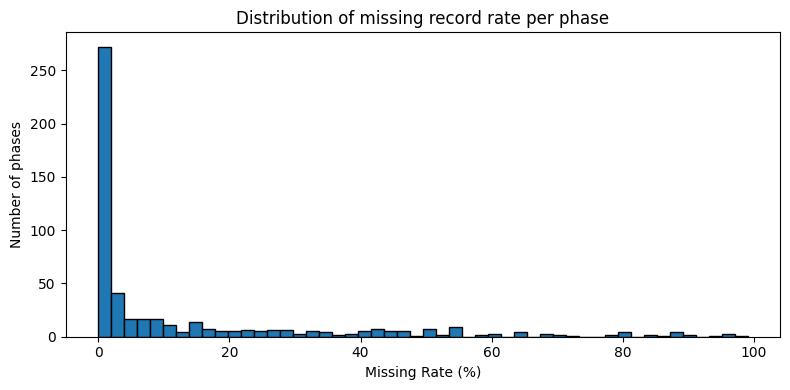

In [91]:
plt.figure(figsize=(8,4))
plt.hist(phase_nb_df["MissingRate (%)"], bins=50, color='tab:blue', edgecolor='black')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Number of phases")
plt.title("Distribution of missing record rate per phase")
plt.tight_layout()
plt.show()

C:\Users\natha\AppData\Local\Temp\ipykernel_27624\3358716229.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


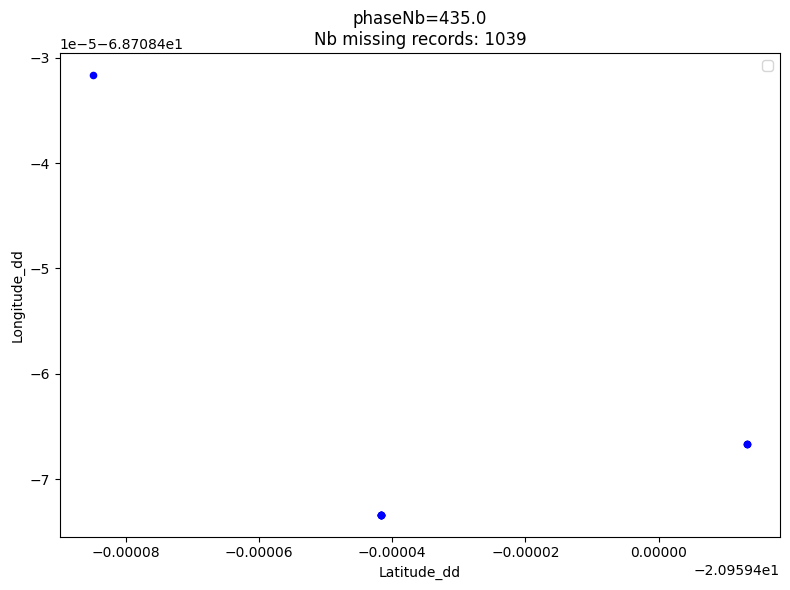

In [92]:
sorted_phase_nb_df = phase_nb_df.sort_values(by="MissingRate (%)", ascending=False)

from IPython.display import clear_output

phases = sorted_phase_nb_df.index.tolist()

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    df_sample = df[df["phaseNb"] == phase_nb]
    nb_missing_records = sorted_phase_nb_df.loc[phase_nb, "NbMissingRecords"]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(df_sample['Latitude_dd'], df_sample['Longitude_dd'], s=20, c="blue")
    ax.set_title(f"phaseNb={phase_nb}\nNb missing records: {nb_missing_records}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    if i < len(phases)-1:
        resp = input('Press Enter to proceed to the next phase (or type "N" to exit the loop)...')
        if resp == "N":
            break